# 25b visualize fine $m_{\rm res}$ visibility scan

`25-scan_visibility_aeff_mres.py` の CSV を読み、$m_{\rm res}$ 近傍での $A_{\rm eff}/A_{\rm unit}$ の oscillatory structure を確認する。


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
CSV = ROOT / 'results' / '25-visibility-mres-fine' / 'visibility_aeff_mres_scan.csv'
df = pd.read_csv(CSV).sort_values("mass_over_mres").reset_index(drop=True)
display(df.head())
df.tail()


,mass_eV,m_res_fid_eV,mass_over_mres,z_rei,delta_y,R_eff_Mpc,phi_unit_at_zrei,dphi_dx_unit_at_zrei,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy,g_norm_z
0,5.119815e-30,1.023963e-29,0.500000,7.7,19.0,34.139,0.004754,1.027937,3.896985e+09,1.879729e+08,0.048235,68.278000,13.530132,0.049521
1,5.361952e-30,1.023963e-29,0.523647,7.7,19.0,34.139,0.004402,-1.083364,-4.107113e+09,-1.467189e+08,0.035723,65.194675,14.170028,0.049521
2,5.615541e-30,1.023963e-29,0.548412,7.7,19.0,34.139,-0.004990,-0.790803,-2.997994e+09,4.046461e+08,-0.134972,62.250588,14.840187,0.049521
3,5.881123e-30,1.023963e-29,0.574349,7.7,19.0,34.139,0.000710,1.555827,5.898258e+09,8.535322e+08,0.144709,59.439451,15.542041,0.049521
4,6.159265e-30,1.023963e-29,0.601513,7.7,19.0,34.139,0.001950,-1.464644,-5.552577e+09,8.068148e+07,-0.014530,56.755261,16.277088,0.049521


,mass_eV,m_res_fid_eV,mass_over_mres,z_rei,delta_y,R_eff_Mpc,phi_unit_at_zrei,dphi_dx_unit_at_zrei,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy,g_norm_z
26,1.702314e-29,1.023963e-29,1.662476,7.7,19.0,34.139,-0.001327,1.226341,4.649149e+09,-9.864945e+07,-0.021219,20.535036,44.987035,0.049521
27,1.782823e-29,1.023963e-29,1.741101,7.7,19.0,34.139,-0.000082,1.640162,6.217979e+09,5.500401e+08,0.088460,19.607707,47.114658,0.049521
28,1.867140e-29,1.023963e-29,1.823445,7.7,19.0,34.139,0.001754,-0.473490,-1.795037e+09,1.244442e+08,-0.069327,18.722254,49.342904,0.049521
29,1.955445e-29,1.023963e-29,1.909683,7.7,19.0,34.139,-0.001657,0.539088,2.043724e+09,-2.066157e+08,-0.101098,17.876787,51.676533,0.049521
30,2.047926e-29,1.023963e-29,2.000000,7.7,19.0,34.139,-0.000235,-1.637342,-6.207286e+09,-6.258415e+08,0.100824,17.069500,54.120530,0.049521


In [2]:
peak_idx = df["Aeff_over_Aunit"].abs().idxmax()
peak = df.loc[[peak_idx], ["mass_eV", "mass_over_mres", "Aeff_over_Aunit", "lambda_osc_Mpc", "N_osc_patchy"]]
mres_idx = (df["mass_over_mres"] - 1.0).abs().idxmin()
mres_row = df.loc[[mres_idx], ["mass_eV", "mass_over_mres", "Aeff_over_Aunit", "lambda_osc_Mpc", "N_osc_patchy"]]
display(peak)
display(mres_row)


,mass_eV,mass_over_mres,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy
15,1.023963e-29,1.0,0.733941,34.139,27.060265


,mass_eV,mass_over_mres,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy
15,1.023963e-29,1.0,0.733941,34.139,27.060265


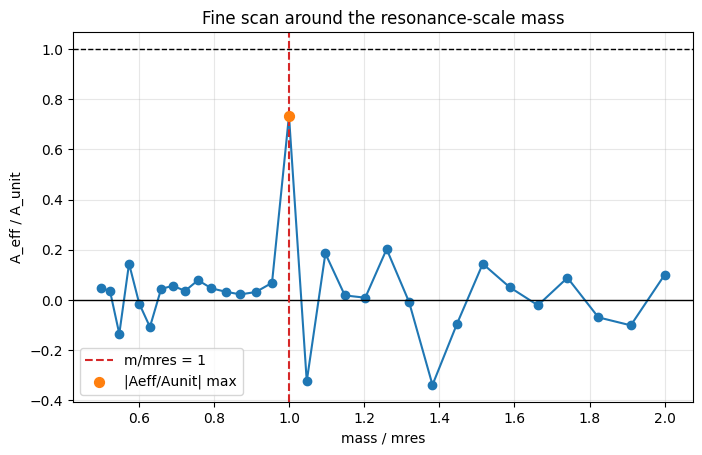

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(df["mass_over_mres"], df["Aeff_over_Aunit"], marker="o")
ax.axhline(0.0, color="black", lw=1)
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.axvline(1.0, color="C3", lw=1.5, ls="--", label="m/mres = 1")
ax.scatter(df.loc[peak_idx, "mass_over_mres"], df.loc[peak_idx, "Aeff_over_Aunit"], color="C1", s=50, zorder=5, label="|Aeff/Aunit| max")
ax.set_xlabel("mass / mres")
ax.set_ylabel("A_eff / A_unit")
ax.set_title("Fine scan around the resonance-scale mass")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


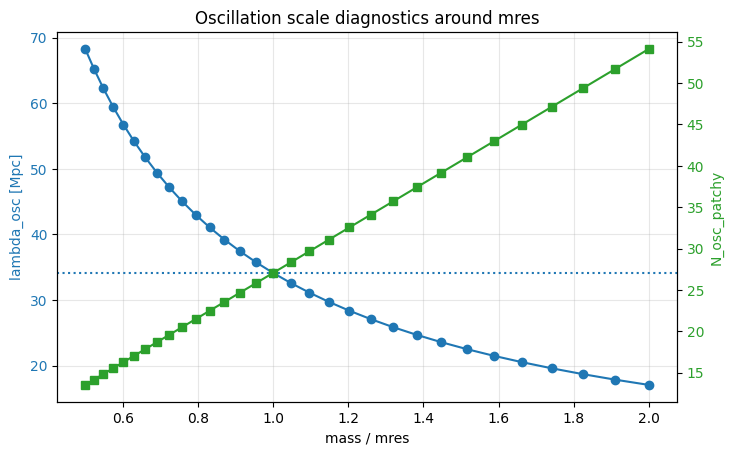

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(df["mass_over_mres"], df["lambda_osc_Mpc"], marker="o", color="C0", label="lambda_osc [Mpc]")
ax1.set_xlabel("mass / mres")
ax1.set_ylabel("lambda_osc [Mpc]", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.axhline(df["R_eff_Mpc"].iloc[0], color="C0", ls=":", lw=1.5)
ax2 = ax1.twinx()
ax2.plot(df["mass_over_mres"], df["N_osc_patchy"], marker="s", color="C2", label="N_osc_patchy")
ax2.set_ylabel("N_osc_patchy", color="C2")
ax2.tick_params(axis="y", labelcolor="C2")
ax1.set_title("Oscillation scale diagnostics around mres")
ax1.grid(True, alpha=0.3)
plt.show()
